In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("geotech_kmeans_homework.ipynb")

In [44]:
# Initialize Otter
import otter
grader = otter.Notebook("geotech_kmeans_homework.ipynb")

# Geotechnical and Geoenvironmental Engineering: Clustering Compaction Tests with K-means

> **Mohamad M. Hallal, PhD** <br> Teaching Professor, UC Berkeley

[![License](https://img.shields.io/badge/license-CC%20BY--NC--ND%204.0-blue)](https://creativecommons.org/licenses/by-nc-nd/4.0/)
***

## About this Assignment

A regional geotechnical laboratory recently conducted Proctor compaction tests on **36 soil specimens** collected from various sites. Unfortunately, the spreadsheet linking each test to its original soil description was corrupted, and only the raw compaction data and index properties remain.

Your task is to use **unsupervised machine learning**, specifically K-means clustering via SciPy, to recover likely soil groupings from the compaction results. You will:

1. Fit polynomial curves to the raw Proctor data and extract optimum moisture content (OMC) and maximum dry density (MDD).
2. Assemble those quantities into a feature matrix alongside grain-size and Atterberg limit data.
3. Cluster the tests with `scipy.cluster.vq.kmeans2`.
4. Use geotechnical reasoning to identify which cluster corresponds to **sandy**, **silty**, and **clayey** soil families.

In [45]:
# Please run this cell, and do not modify the contents

import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import whiten, kmeans2, vq

plt.rcParams["figure.figsize"] = (7, 5)
pd.set_option("display.max_columns", 20)

## Background: Proctor Test and Soil-Type Differences

The **Standard Proctor compaction test** (ASTM D698) determines how dry unit weight varies with water content for a given soil. Soil is compacted in a standardized mold at several water contents, and the dry unit weight is measured at each point. The resulting **compaction curve** is approximately parabolic and has a well-defined peak:

| Quantity | Symbol | Units | Meaning |
|---|---|---|---|
| **Optimum Moisture Content** | OMC | % | Water content at maximum dry unit weight |
| **Maximum Dry Density** | MDD | kN/m³ | Peak dry unit weight on the compaction curve |

---

### How soil type affects compaction behavior

Different soil families behave quite differently under compaction:

**Sandy soils (coarse-grained)**
- Low OMC — sand needs relatively little water to lubricate particle contact
- Relatively high MDD — dense particle packing is achievable at low water contents
- Low fines content, low or non-plastic Atterberg limits

**Silty soils (intermediate)**
- Moderate OMC and MDD
- Moderate fines content, low to moderate plasticity

**Clayey soils (fine-grained)**
- High OMC — clay platelets require substantial water to rearrange
- Lower MDD — excess water displaces particles that could otherwise be packed together
- High fines content, high liquid limit and plasticity index

These systematic differences form the physical basis for the clustering you will perform in this assignment.

## Part 1: Load the Data

Run the cell below to load both CSV files. You do not need to modify this cell.

- **`curves`** — This table holds the data regarding the compaction tests performed on the soil samples. test_id refers to the specific sample of soil while point_id refers to a specific test done to that sample. Looking at the data, you cansee that for soil T01 there were 5 tests done, each giving us a different point on the moisture content vs dry unit weight curve.
---
- **`features`** — This gives a row of features, with each row representing a specific soil sample. As you can see, the test_id lets you match the features of the soil sample to the compaction test data in the curves table.
---

> **Note:** You may have noticed that `omc_pct` (optimum moisture content percentage) and `mdd_kN_m3` (maximum dry density in KN per meter cubed) are both given in the features table. We will calculate these values ourselves in questions 1 and 2, but feel free to look back at the features table for reference on what the values should roughly be.

In [ ]:
# Run this cell — do not modify this part
compaction_tests   = pd.read_csv("resources/proctor_curves.csv")
features = pd.read_csv("resources/soil_compaction_features.csv")

# Printing out table shapes and sample of the table
print("compaction_tests table shape:", compaction_tests.shape)
print("featrure table shape:", features.shape)

print("\ncompaction_tests table (first 10 rows):")
display(compaction_tests.head(10))

print("\nFeature summary (first 5 rows):")
display(features.head())

## Question 1: Fit a Polynomial to a Compaction Curve

Taking the raw maximum of the proctor test data to be the maximum dry density is straightforward, but it is sensitive to measurement noise: if one test point happens to be slightly high or low, the estimated peak shifts. Fitting a **polynomial** to the compaction data and then finding its peak is more robust and is standard practice in automated Proctor data analysis.

Write a function named `fitProctorCurve` that fits a polynomial of a given degree to a set of compaction measurements and returns the resulting polynomial as a usable function.

### Input arguments

| Argument | Type | Description |
|---|---|---|
| `moisture_pcts` | array-like | Moisture content values for each compaction point (%) |
| `dry_unit_weights` | array-like | Corresponding dry unit weights (kN/m³) |
| `degree` | int | Degree of the fitting polynomial (default `2`) |

### Output

| Return value | Type | Description |
|---|---|---|
| `poly_fn` | `numpy.poly1d` | Polynomial function fitted to the compaction data |

---
We have provided sample code below that creates a figure using the `fitProctorCurve()` function that you create. Use it to visualize and verify your line fitting. An example curve fitted to a two degree polynomial is shown below.
<center><img src="resources/Curve_Example.png" width='650'/></center>
    
---
For testing purposes, please use np.polyfit in order to fit your polynomials. If you don't, your code may not pass the autograder. Documentation is linked below. We also encourage querying an AI tool to help with the process if you don't quite understand how the functions work.
- np.polyfit (getting polynmial coefficients): https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
- np.poly1d (turning coefficients into usable function): nhttps://numpy.org/doc/stable/reference/generated/numpy.poly1d.html

In [26]:
def fitProctorCurve(moisture_pcts, dry_unit_weights, degree=2):
    # Convert to NumPy arrays for use
    moisture_pcts    = np.array(moisture_pcts)
    dry_unit_weights = np.array(dry_unit_weights)
    
    # Get polynomial coefficients using np.polyfit
    coeffs = np.polyfit(moisture_pcts, dry_unit_weights, degree) # SOLUTION

    # Create function from coefficients using np.poly1d
    curve = np.poly1d(coeffs) # SOLTION

    return curve

### Helper Visualization

Run the cell below after implementing `fitProctorCurve` to see the fitted curve for the first sample in the dataset (T01). A good fit will pass smoothly through the data points and show a clear peak.

In [ ]:
# Helper cell: plots one fitted compaction curve. We made this using an AI tool, and encourage using LLMs to quickly scope out how data looks like by plotting.
example_id = "T01"

one_curve = compaction_tests[compaction_tests["test_id"] == example_id].sort_values("moisture_content_pct")
w  = one_curve["moisture_content_pct"].to_numpy()
gd = one_curve["dry_unit_weight_kN_m3"].to_numpy()

poly_fn_example = fitProctorCurve(w, gd, degree=2)
w_smooth = np.linspace(w.min(), w.max(), 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(w, gd, color="black", zorder=5, s=50, label="Measured points")
ax.plot(w_smooth, poly_fn_example(w_smooth), color="royalblue", linewidth=2,
        label="Degree-2 polynomial fit")
ax.set_xlabel("Moisture Content (%)")
ax.set_ylabel("Dry Unit Weight (kN/m³)")
ax.set_title(f"Proctor compaction curve — Test {example_id}")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.show()

#### Testing Cell:

In [ ]:
grader.check("q1")

## Question 2: Extract OMC and MDD from the Fitted Curve

Now that you can fit a polynomial to a compaction curve, you need to find its **peak** — the point where dry unit weight is maximized. This peak defines the OMC (Optimal Moisture Content) and MDD (Maximum Dry Density).

For a degree-2 polynomial, the peak is a single well-defined maximum that can be found using basic calculus. For higher degree polynomials, a practical and numerically robust approach is to evaluate the polynomial at many closely spaced moisture content values and find which one gives the highest dry unit weight. This sampling method is an example of a procedure called grid search, and is relatively easy in this case since were trying to maximize across a 1D domain which is bounded.

Write a function named `computeOMC_MDD` that returns the OMC and MDD from a fitted polynomial by sampling the polynomial in 1000 equally spaced points from w_min to w_max.

### Input arguments

| Argument | Type | Description |
|---|---|---|
| `poly` | `numpy.poly1d` | Polynomial function from `fitProctorCurve` |
| `w_min` | float | Lower bound of the moisture content range (%) |
| `w_max` | float | Upper bound of the moisture content range (%) |

### Output

| Return value | Type | Description |
|---|---|---|
| `omc` | float | Optimum moisture content (%) |
| `mdd` | float | Maximum dry unit weight (kN/m³) |

### Hints
- Create a dense array of moisture contents with `np.linspace(w_min, w_max, 1000)`.
- Evaluate the polynomial at each point with `poly_fn(w_dense)`.
- Use `np.argmax` to locate the index of the maximum dry unit weight.
- Return `omc` and `mdd` as Python `float` values (cast with `float(...)`).

In [29]:
def computeOMC_MDD(poly, w_min, w_max):

    # Making array of equally spaced points to call the function on
    moisture_contents  = np.linspace(w_min, w_max, 1000)

    # Use the poly function to get densities at specified moisture contents 
    dry_densities = poly(moisture_contents)           # SOLUTION

    # get the index of this dry density array with the max value
    idx_max  = np.argmax(dry_densities)               # SOLUTION

    # Extract the values for optimum moisture content and maximum dry density using this index
    omc = float(moisture_contents[idx_max])                     
    mdd = float(dry_densities[idx_max])    # SOLUTION                
    return omc, mdd

### Helper Visualization

The cell below fits curves for six representative tests, two from each expected soil family, and marks the OMC (vertical dashed red line) and MDD (horizontal dashed green line). Notice how OMC increases and MDD decreases as you move from sandy to clayey soils. Try changing which sample_tests to see how your function performs on different samples. You can compare them with the values in the tables to see how you're doing.

In [ ]:
# Helper: show fitted curves with OMC and MDD for six tests
sample_tests = ["T01", "T03", "T15", "T22", "T27", "T33"]



fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, tid in enumerate(sample_tests):
    one = compaction_tests[compaction_tests["test_id"] == tid].sort_values("moisture_content_pct")
    w   = one["moisture_content_pct"].to_numpy()
    gd  = one["dry_unit_weight_kN_m3"].to_numpy()

    poly = fitProctorCurve(w, gd, degree=2)
    omc, mdd = computeOMC_MDD(poly, w.min(), w.max())

    w_smooth = np.linspace(w.min(), w.max(), 300)
    axes[i].scatter(w, gd, color="black", s=20, zorder=5)
    axes[i].plot(w_smooth, poly(w_smooth), color="royalblue")
    axes[i].axvline(omc, color="red",   linestyle="--",
                    label=f"OMC = {omc:.1f}%")
    axes[i].axhline(mdd, color="green", linestyle="--",
                    label=f"MDD = {mdd:.2f} kN/m³")
    axes[i].set_title(f"Test {tid}")
    axes[i].set_xlabel("w (%)")
    axes[i].set_ylabel("γd (kN/m³)")
    axes[i].legend(fontsize=7)
    axes[i].grid(True, linestyle=":", linewidth=0.6)

plt.suptitle("Fitted compaction curves with OMC and MDD", fontsize=13)
plt.tight_layout()
plt.show()

### Recover OMC and MDD for all 36 tests

Run the cell below to apply your two functions to every test in the dataset and compare the curve-derived OMC/MDD against the pre-computed values in the features file. Small differences are expected — the feature file values were generated from a finer polynomial evaluation, so discrepancies of less than **0.5%** for OMC and **0.05 kN/m³** for MDD are normal.

In [ ]:
# Helper: apply fitProctorCurve + computeOMC_MDD to all tests
records = []
for tid, grp in compaction_tests.groupby("test_id"):
    grp = grp.sort_values("moisture_content_pct")
    w   = grp["moisture_content_pct"].to_numpy()
    gd  = grp["dry_unit_weight_kN_m3"].to_numpy()
    poly = fitProctorCurve(w, gd, degree=2)
    omc, mdd = computeOMC_MDD(poly, w.min(), w.max())
    records.append({"test_id": tid, "omc_curve": round(omc, 2), "mdd_curve": round(mdd, 3)})

curve_summary = pd.DataFrame(records)
comparison = features[["test_id", "omc_pct", "mdd_kN_m3"]].merge(curve_summary, on="test_id")
comparison["omc_diff"] = (comparison["omc_curve"] - comparison["omc_pct"]).round(3)
comparison["mdd_diff"] = (comparison["mdd_curve"] - comparison["mdd_kN_m3"]).round(4)

print("=== OMC and MDD: feature file vs. curve-derived ===")
display(comparison)
print(f"\nMax |OMC diff|: {comparison['omc_diff'].abs().max():.3f} %")
print(f"Max |MDD diff|: {comparison['mdd_diff'].abs().max():.4f} kN/m³")

#### Testing Cell:

In [ ]:
grader.check("q2")

## Background: Building a Feature Matrix for Clustering

We will now begin the process of applying K-means to the data. K-means treats each observation as a point in a multi-dimensional feature space and groups observations by proximity to cluster centroids. For this to work well:

1. **Each row** of the feature matrix must represent one observation (one compaction test).
2. **Each column** must represent one numerical feature.
3. The features must be on a **comparable scale**. Otherwise a variable measured in the tens (e.g. OMC ≈ 10–25%) will dominate a variable measured in the ones (e.g. specific gravity ≈ 2.67), and the clustering will effectively ignore the smaller-scale variable.

### Whitening

SciPy’s `scipy.cluster.vq.whiten` rescales each feature by dividing it by its sample standard deviation, so that every whitened feature has a standard deviation of 1.0. The clustering then treats all features equally in Euclidean distance calculations.

$$\tilde{x}_j = \frac{x_j}{\sigma_j}$$

where $x_j$ is the original feature column and $\sigma_j$ is its sample standard deviation.

> **Important:** `whiten` does **not** center the data (i.e. it does not subtract the mean). It only scales by the standard deviation. The whitened features will still be offset from zero if the original features were.
---
We have decided to implement the process for you so that you can focus on the procedure and the results. Take a quick look at the code to get an idea of what is being done. Please don't edit the code since the results will be used in future parts

In [33]:
# This function takes in the features table, along with the columns that we want to use in the table. It drops any rows with missing values, converts it into a Numpy array data structure, 
# and then returns both the raw array and the whitened version to be used in the K-means algorithm.
def buildFeatureMatrix(features_table, feature_cols):

    # Keep only the feature_cols
    df    = features_table[feature_cols]

    # Drop rows with missing values
    df    = df.dropna()

    # Convert to numpy array
    features_numpy   = df.to_numpy()                     
    features_whitened = whiten(features_numpy)                           
    return features_numpy, features_whitened

### Choosing features and inspecting the whitened matrix

Run the cell below to build the feature matrix with a default set of four columns. After whitening, the standard deviation of each column should be **exactly 1.0**. You can add or remove columns from `feature_cols` to explore how your choice affects the clustering in later questions. For now, we have chosen to perform k_means using the optimum moisture content and max dry density, which means that K-means will group specimens based soley on their compaction test data.

In [34]:
# Define the feature columns to use for clustering
# You may add or remove columns, but start with these two
feature_cols = [
    "omc_pct",
    "mdd_kN_m3"
]

features_numpy, features_whitened = buildFeatureMatrix(features, feature_cols)

print(f"Feature matrix shape: {features_numpy.shape}  (rows = tests, cols = features)")

print("\n=== Original feature statistics ===")
display(pd.DataFrame(features_numpy, columns=feature_cols).describe().round(2))

print("\n=== Whitened feature statistics (std should be ≈ 1 for each column) ===")
display(pd.DataFrame(features_whitened, columns=[c + "_w" for c in feature_cols]).describe().round(2))

Feature matrix shape: (36, 2)  (rows = tests, cols = features)

=== Original feature statistics ===


,omc_pct,mdd_kN_m3
count,36.00,36.00
mean,15.44,17.72
std,4.53,1.29
min,8.83,15.42
25%,10.91,16.53
50%,15.01,17.95
75%,19.08,18.85
max,23.58,19.61



=== Whitened feature statistics (std should be ≈ 1 for each column) ===


,omc_pct_w,mdd_kN_m3_w
count,36.00,36.00
mean,3.45,13.91
std,1.01,1.01
min,1.98,12.10
25%,2.44,12.97
50%,3.36,14.09
75%,4.27,14.79
max,5.28,15.39


## Background: K-means Clustering

K-means partitions observations into $k$ groups by iteratively:

1. Assigning each observation to the nearest centroid (in Euclidean distance).
2. Recomputing each centroid as the mean of its assigned observations.

The algorithm converges when assignments stop changing. SciPy provides two implementations:

| Function | Returns | Notes |
|---|---|---|
| `kmeans(obs, k_or_guess)` | `(centroids, distortion)` | Returns only the centroids and total distortion |
| `kmeans2(data, k)` | `(centroids, labels)` | Also returns per-observation cluster labels |

We will use **`kmeans2`** because it returns both centroids and labels in one call.

### Initialization

The final clusters can depend on where the algorithm starts. `kmeans2` offers several initializing options:

| `minit` value | Description |
|---|---|
| `"random"` | Randomly chosen initial centroids |
| `"points"` | Randomly chosen observations as initial centroids |
| `"++"` | K-means++ — spreads initial centroids out deliberately; more robust |

We will use `"++"` and fix the random seed so that results are reproducible.

### Why $k = 3$?

We are looking for three broad soil families: sandy, silty, and clayey. In a real investigation you might use the **elbow method** or the **silhouette score** to choose $k$ empirically. Here we set $k = 3$ because we have prior geotechnical knowledge about how many groups to expect. In the reflection section you will examine what happens when $k$ is different.

## Question 3: Cluster the Compaction Tests

Write a function named `clusterSoils` that applies `kmeans2` to a whitened feature matrix and returns the cluster centroids and per-observation labels.

### Input arguments

| Argument | Type | Description |
|---|---|---|
| `features_whitened` | `numpy.ndarray` | Whitened feature matrix from `buildFeatureMatrix` |
| `k` | int | Number of clusters |
| `seed` | int | Random seed for reproducibility (default `0`) |

### Output

| Return value | Type | Description |
|---|---|---|
| `centroids_white` | `numpy.ndarray`, shape (k, p) | Cluster centroids in whitened space |
| `labels` | `numpy.ndarray`, shape (n,) | Cluster index (0 to k-1) for each observation |

### Hints
- Call `kmeans2(features_whitened, k, minit="++", rng=seed)`.
- `kmeans2` returns `(centroids, labels)` directly.

In [35]:
# Note seed was changed to rng in newer version of scipy. May need to change later.
def clusterSoils(f_whitened, k, seed=0):
    centroids_white, labels = kmeans2(f_whitened, k, minit="++", seed=seed)  # SOLUTION
    return centroids_white, labels

### Run clustering and visualize the result

Run the cell below to cluster the 36 tests into three groups and see how they separate in two different 2D projections of the feature space. If the clustering is working well, the three groups should be visually distinct in at least one of the two plots.

=== Cluster counts ===


cluster
0    12
1    12
2    12
Name: n_tests, dtype: int64

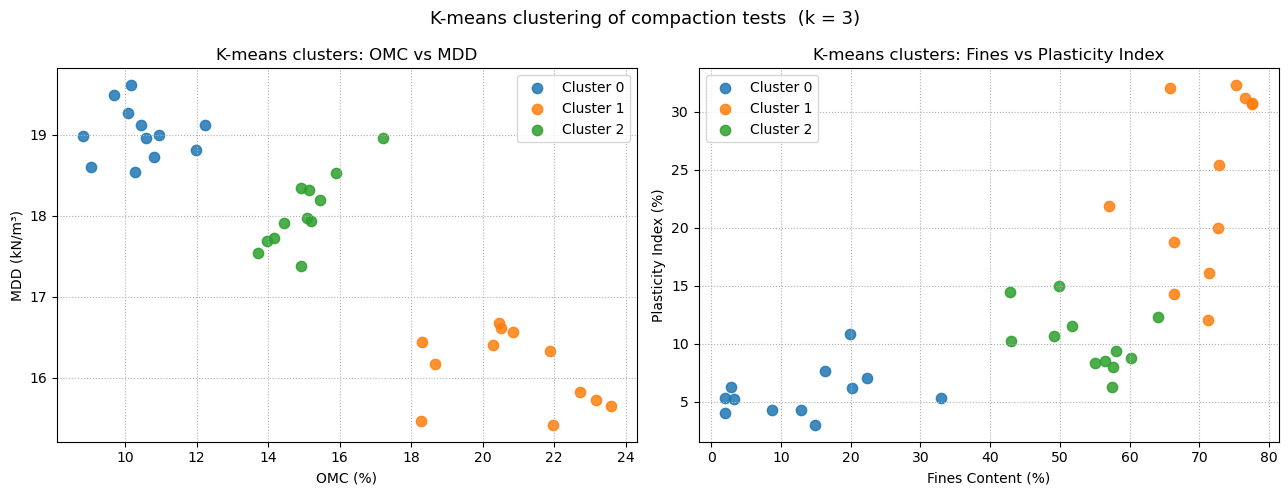

In [36]:
# Cluster the soils and inspect the results
k = 3
centroids_white, labels = clusterSoils(features_whitened, k=k, seed=0)

df_clustered = features.dropna(subset=feature_cols).copy()
df_clustered["cluster"] = labels

print("=== Cluster counts ===")
display(df_clustered["cluster"].value_counts().sort_index().rename("n_tests"))

colors = ["tab:blue", "tab:orange", "tab:green"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: OMC vs MDD
for cl in range(k):
    mask = df_clustered["cluster"] == cl
    axes[0].scatter(df_clustered.loc[mask, "omc_pct"],
                    df_clustered.loc[mask, "mdd_kN_m3"],
                    color=colors[cl], label=f"Cluster {cl}", s=55, alpha=0.85)
axes[0].set_xlabel("OMC (%)")
axes[0].set_ylabel("MDD (kN/m³)")
axes[0].set_title("K-means clusters: OMC vs MDD")
axes[0].legend()
axes[0].grid(True, linestyle=":", linewidth=0.8)

# Plot 2: Fines vs Plasticity Index
for cl in range(k):
    mask = df_clustered["cluster"] == cl
    axes[1].scatter(df_clustered.loc[mask, "fines_pct"],
                    df_clustered.loc[mask, "plasticity_index_pct"],
                    color=colors[cl], label=f"Cluster {cl}", s=55, alpha=0.85)
axes[1].set_xlabel("Fines Content (%)")
axes[1].set_ylabel("Plasticity Index (%)")
axes[1].set_title("K-means clusters: Fines vs Plasticity Index")
axes[1].legend()
axes[1].grid(True, linestyle=":", linewidth=0.8)

plt.suptitle("K-means clustering of compaction tests  (k = 3)", fontsize=13)
plt.tight_layout()
plt.show()

#### Testing Cell:

In [ ]:
grader.check("q3")

## Background: Interpreting Cluster Centroids

K-means assigns each test to a numbered cluster (0, 1, 2), but it has no knowledge of soil science. To translate cluster numbers into soil-type labels, you need to examine the **centroid values** in engineering units and reason about what type of soil they most likely represent.

### Converting centroids back to engineering units

The centroids returned by `kmeans2` are in **whitened space** — each feature has been divided by its sample standard deviation. To interpret the centroids physically, multiply each column of the centroid matrix by the corresponding standard deviation of the original feature:

$$\text{centroid in original units} = \tilde{c}_j \times \sigma_j$$

where $\tilde{c}_j$ is the centroid value in whitened space and $\sigma_j$ is the standard deviation of feature $j$ computed from the original features data.

### Centroid helper

Run this cell to display the values of the cluster centroid with respect to the original units of our table. We are essentially resizing the values back to what they're supposed to be using the idea described above. Use the values to guide your answer in the problem below.

In [38]:
# Helper: centroid table in approximate engineering units
feature_stds = features_numpy.std(axis=0)
centroids_eng = centroids_white * feature_stds

centroid_df = pd.DataFrame(centroids_eng, columns=feature_cols)
centroid_df.index.name = "Cluster"

print("=== Cluster centroids (in original engineering units) ===")
display(centroid_df.round(3))
print("Compare clusters relative to each other, not to absolute benchmarks.")

=== Cluster centroids (in original engineering units) ===


,omc_pct,mdd_kN_m3
Cluster,,
0,10.422,19.019
1,20.892,16.108
2,15.008,18.042


Compare clusters relative to each other, not to absolute benchmarks.


## Question 5: Map Cluster Numbers to Soil Groups

Study the centroid table printed by the helper cell above, then assign each cluster number to the soil group you believe it most likely represents.

Create a dictionary named `q5` that maps each cluster index (0, 1, 2) to one of the following **exact strings**: `"Sandy"`, `"Silty"`, or `"Clayey"`.

Each soil group must be assigned to **exactly one** cluster.

### Example (do not copy directly — use your own interpretation)

```python
q5 = {
    0: "Clayey",
    1: "Sandy",
    2: "Silty",
}
```

### Hints
- Run the centroid helper cell above before filling in your answer.
- The cluster with the **lowest OMC and highest MDD** is most likely sandy.
- The cluster with the **highest OMC and lowest MDD** is most likely clayey.

### What to look for

Use the table below as a reference when examining the centroid values:

| Soil type | OMC | MDD | Fines | Plasticity Index |
|---|---|---|---|---|
| Sandy | Low (≈10–12%) | High (≈18–19 kN/m³) | Low (<25%) | Low (<8%) |
| Silty | Moderate (≈14–16%) | Moderate (≈17–18 kN/m³) | Moderate (40–60%) | Low–moderate (<12%) |
| Clayey | High (>18%) | Low (<17 kN/m³) | High (>60%) | High (>15%) |

In [39]:
# TODO: replace the values below with your interpretation
q5 = {
    0: "Sandy",   # SOLUTION
    2: "Silty",   # SOLUTION
    1: "Clayey",  # SOLUTION
}

### Labeled scatter plot

Once you have filled in `q5`, run the helper cell below to see your predicted soil groups plotted with respect to their pasticity index and fines content. If things were done correctly, you should see that we have been able to categorize our soils correctly into sands, silts, and clays, a classification which has to do only with fines percentage and plasticity index. We did this using an algorithm which groups specimens based only on OMC and MDD! Hopefully this result helps to show how unsupervised learning tools like K-means can help in finding relationships in data that were previously hidden.

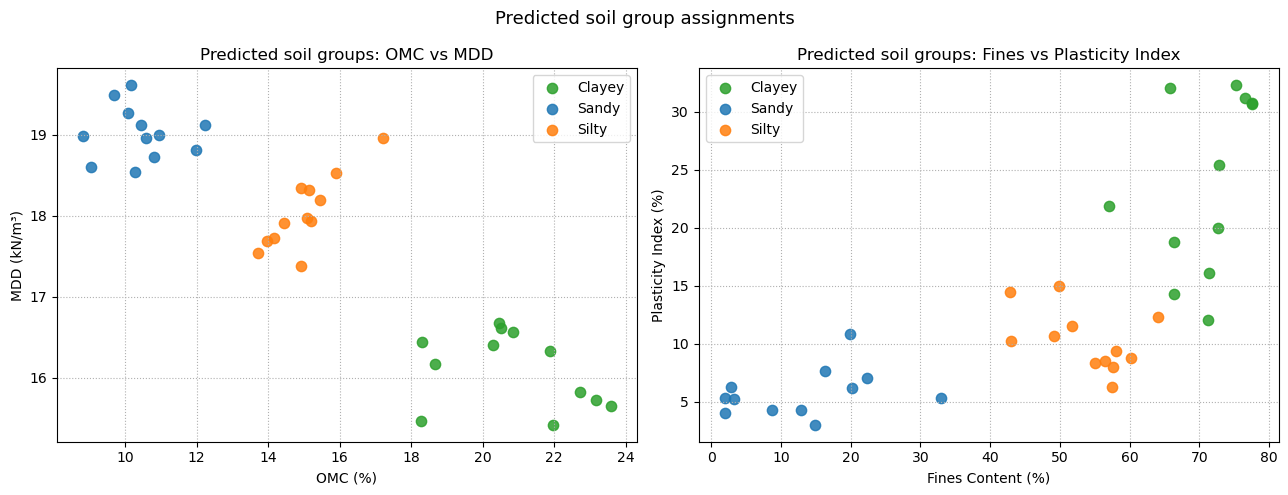


=== Tests per predicted soil group ===


soil_group
Sandy     12
Silty     12
Clayey    12
Name: n_tests, dtype: int64

In [40]:
# Helper: scatter plot labeled by your predicted soil group
df_labeled = df_clustered.copy()
df_labeled["soil_group"] = df_labeled["cluster"].map(q5)

group_colors = {"Sandy": "tab:blue", "Silty": "tab:orange", "Clayey": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for group, grp_df in df_labeled.groupby("soil_group"):
    axes[0].scatter(grp_df["omc_pct"], grp_df["mdd_kN_m3"],
                    color=group_colors[group], label=group, s=55, alpha=0.85)
axes[0].set_xlabel("OMC (%)")
axes[0].set_ylabel("MDD (kN/m³)")
axes[0].set_title("Predicted soil groups: OMC vs MDD")
axes[0].legend()
axes[0].grid(True, linestyle=":", linewidth=0.8)

for group, grp_df in df_labeled.groupby("soil_group"):
    axes[1].scatter(grp_df["fines_pct"], grp_df["plasticity_index_pct"],
                    color=group_colors[group], label=group, s=55, alpha=0.85)
axes[1].set_xlabel("Fines Content (%)")
axes[1].set_ylabel("Plasticity Index (%)")
axes[1].set_title("Predicted soil groups: Fines vs Plasticity Index")
axes[1].legend()
axes[1].grid(True, linestyle=":", linewidth=0.8)

plt.suptitle("Predicted soil group assignments", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Tests per predicted soil group ===")
display(df_labeled["soil_group"].value_counts().rename("n_tests"))

### Compare against the instructor answer key

The file `instructor_answer_key.csv` contains the true soil group for each test. Run the cell below to see how well your cluster-to-group mapping recovered the original labels.

In [41]:
# Helper: compare predictions to the answer key
answer_key = pd.read_csv("resources/instructor_answer_key.csv")

comparison = df_labeled[["test_id", "soil_group"]].merge(
    answer_key, on="test_id"
)

# Rename answer key column if needed
true_col = [c for c in answer_key.columns if c != "test_id"][0]
comparison = comparison.rename(columns={true_col: "true_group"})

comparison["correct"] = comparison["soil_group"] == comparison["true_group"]
accuracy = comparison["correct"].mean()

print(f"Accuracy: {accuracy:.1%}  ({comparison['correct'].sum()}/{len(comparison)} tests correct)")
display(comparison)

Accuracy: 100.0%  (36/36 tests correct)


,test_id,soil_group,true_group,correct
0,T01,Sandy,Sandy,True
1,T02,Sandy,Sandy,True
2,T03,Sandy,Sandy,True
3,T04,Sandy,Sandy,True
4,T05,Sandy,Sandy,True
5,T06,Sandy,Sandy,True
6,T07,Sandy,Sandy,True
7,T08,Sandy,Sandy,True
8,T09,Sandy,Sandy,True
9,T10,Sandy,Sandy,True


#### Testing Cell:

In [ ]:
grader.check("q4")

## Reflection

Answer the following questions in the markdown cells provided.

### Reflection 1

Re-run the clustering using different variables in feature_cols. Compare the resulting patterns that the algorithm picks up in the data depending on what features you select.

**How does changing the features to run on change the clusterings. Are there any new associations that you can see?**

**Your answer:**

*[double-click to edit]*

### Reflection 2

Re-run `clusterSoils` with `k = 2` and `k = 4`. Describe what you observe in the resulting scatter plots.

**What happens to the silty group when $k = 2$? Does increasing to $k = 4$ produce a geotechnically meaningful fourth group, or does it split an existing group arbitrarily?**

**Your answer:**

*[double-click to edit]*

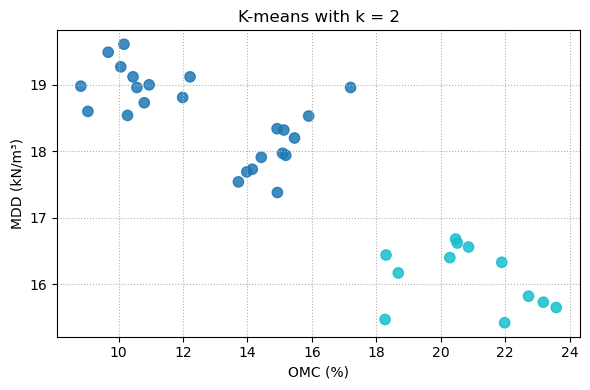

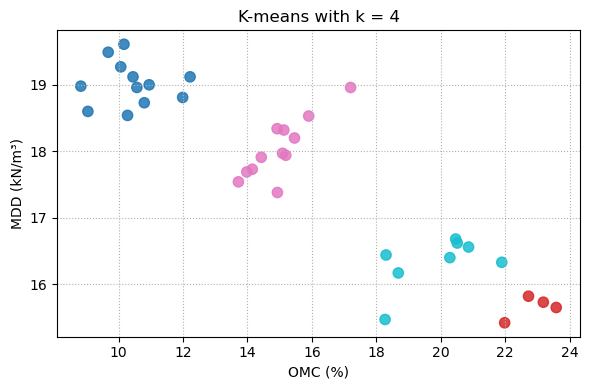

In [43]:
# Exploration cell: try k=2 and k=4
# Re-use buildFeatureMatrix and clusterSoils from above

for k_test in [2, 4]:
    c_w, lbs = clusterSoils(features_whitened, k=k_test, seed=0)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(features.dropna(subset=feature_cols)["omc_pct"],
               features.dropna(subset=feature_cols)["mdd_kN_m3"],
               c=lbs, cmap="tab10", s=55, alpha=0.85)
    ax.set_xlabel("OMC (%)")
    ax.set_ylabel("MDD (kN/m³)")
    ax.set_title(f"K-means with k = {k_test}")
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()

### Reflection 3

K-means assumes that clusters are roughly **spherical and equal in size** in the feature space, and it uses Euclidean distance as its similarity measure.

**Give a concrete geotechnical scenario where these assumptions might cause K-means to incorrectly group two tests that a geotechnical engineer would classify differently. Use specific feature values in your example.**

**Your answer:**

*[double-click to edit]*

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

Make sure you submit the .zip file to Gradescope.

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False)